# 07 Complaint construct analysis

This notebook merges the chief-complaint lookup table back into the three analytic datasets, constructs encounter-level scores using only **patient-reported** and **non-trauma** complaint components, draws demographic boxplots with mean ± 95% CI overlays, and runs one-way ANOVA tests for group differences.

In [1]:
from pathlib import Path
from json import JSONDecoder
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

ROOT = Path(".")
MAIN = ROOT / "main"
SHARED = MAIN / "shared"
OUT_DIR = MAIN / "construct_robustness"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAD_PATH = SHARED / "radiology" / "radiology_analytic_imputed.parquet"
PRESSOR_PATH = SHARED / "pressor" / "pressor_analytic_imputed.parquet"
VENT_PATH = SHARED / "vent" / "vent_analytic_imputed.parquet"
LOOKUP_PATH = MAIN / "chief_complaint_lookup_table.jsonl"

TEXT_COL = "chiefcomplaint"
NO_CC_TOKEN = "no_cc"

DATASET_PATHS = {
    "radiology": RAD_PATH,
    "pressor": PRESSOR_PATH,
    "vent": VENT_PATH,
}

DEMOGRAPHIC_VARS = ["gender", "race", "language"]
SCORE_COLS = ["cc_pt_nontrauma_acuity_max", "cc_pt_nontrauma_severity_max", "cc_pt_nontrauma_specificity_mean"]
SCORE_LABELS = {
    "cc_pt_nontrauma_acuity_max": "Acuity",
    "cc_pt_nontrauma_severity_max": "Severity",
    "cc_pt_nontrauma_specificity_mean": "Specificity",
}

ELIGIBLE_TRAUMA_STATUS = {"non_trauma"}
ELIGIBLE_SYMPTOM_TYPES = {"symptom"}

print("Lookup:", LOOKUP_PATH)
for name, path in DATASET_PATHS.items():
    print(name, path)


Lookup: main/chief_complaint_lookup_table.jsonl
radiology main/shared/radiology/radiology_analytic_imputed.parquet
pressor main/shared/pressor/pressor_analytic_imputed.parquet
vent main/shared/vent/vent_analytic_imputed.parquet


In [2]:
ABBREVIATION_PATTERNS = [
    (r"\bn\s*/\s*v\s*/\s*d\b", "nausea vomiting diarrhea"),
    (r"\bn\s*/\s*v\b", "nausea vomiting"),
    (r"\bs\s*/\s*p\b", "status post"),
    (r"^sp\b", "status post"),
    (r"\bsob\b", "shortness of breath"),
    (r"\bcp\b", "chest pain"),
    (r"\babd\b", "abdominal"),
    (r"\bams\b", "altered mental status"),
    (r"\bmvc\b", "motor vehicle collision"),
]

def normalize_component(text: str) -> str:
    x = str(text).strip().lower()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"\s*/\s*", "/", x)
    for pattern, replacement in ABBREVIATION_PATTERNS:
        x = re.sub(pattern, replacement, x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def salvage_json_objects(path: Path):
    if not path.exists():
        return []
    text = path.read_text(encoding="utf-8")
    decoder = JSONDecoder()
    out = []
    i = 0
    n = len(text)
    while i < n:
        while i < n and text[i].isspace():
            i += 1
        if i >= n:
            break
        try:
            obj, j = decoder.raw_decode(text, i)
            out.append(obj)
            i = j
        except json.JSONDecodeError:
            i += 1
    return out

def harmonize_lookup(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "component_examples" not in out.columns:
        if "raw_examples_top5" in out.columns:
            out["component_examples"] = out["raw_examples_top5"].astype("string").fillna("").map(
                lambda s: [x.strip() for x in str(s).split("|") if x.strip()]
            )
        elif "component_example" in out.columns:
            out["component_examples"] = out["component_example"].astype("string").fillna("").map(
                lambda s: [str(s).strip()] if str(s).strip() else []
            )
        else:
            out["component_examples"] = [[] for _ in range(len(out))]

    if "component" not in out.columns:
        if "component_example" in out.columns:
            out["component"] = out["component_example"].astype("string").fillna("").astype(str)
        else:
            out["component"] = out["normalized_component"].astype("string").fillna("").astype(str)

    keep = [
        "normalized_component",
        "component",
        "component_examples",
        "is_informative",
        "canonical_label",
        "trauma_status",
        "body_system",
        "symptom_type",
        "acuity_1to5",
        "severity_1to5",
        "specificity_1to5",
        "red_flag",
        "objective_finding",
        "note",
    ]
    keep = [c for c in keep if c in out.columns]
    out = out.loc[:, keep].copy()
    out["normalized_component"] = out["normalized_component"].astype("string").str.strip()
    out = out.loc[out["normalized_component"].notna() & (out["normalized_component"] != "")].copy()
    out = out.drop_duplicates("normalized_component").reset_index(drop=True)
    return out

def load_lookup_table(path: Path) -> pd.DataFrame:
    objs = salvage_json_objects(path)
    rows = [x for x in objs if isinstance(x, dict)]
    if not rows:
        raise ValueError(f"No valid JSON objects found in {path}")
    return harmonize_lookup(pd.DataFrame(rows))


In [3]:
def extract_component_rows(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    rows = []
    s = df[TEXT_COL].astype("string")
    for row_id, raw in s.items():
        if pd.isna(raw):
            continue
        text = str(raw).strip()
        if text == "" or text.lower() == NO_CC_TOKEN:
            continue
        for part in text.split(","):
            raw_component = part.strip()
            if raw_component == "" or raw_component.lower() == NO_CC_TOKEN:
                continue
            normalized_component = normalize_component(raw_component)
            if normalized_component == "" or normalized_component == NO_CC_TOKEN:
                continue
            rows.append(
                {
                    "dataset": dataset_name,
                    "row_id": int(row_id),
                    "raw_component": raw_component,
                    "normalized_component": normalized_component,
                }
            )
    return pd.DataFrame(rows)

def build_encounter_scores(df: pd.DataFrame, dataset_name: str, lookup: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    base = df.reset_index(drop=True).copy()
    base["_row_id"] = np.arange(len(base), dtype=int)

    comp = extract_component_rows(base, dataset_name=dataset_name)
    if comp.empty:
        merged = base.copy()
        merged["cc_pt_nontrauma_component_n"] = 0
        merged["cc_pt_nontrauma_acuity_max"] = np.nan
        merged["cc_pt_nontrauma_severity_max"] = np.nan
        merged["cc_pt_nontrauma_specificity_mean"] = np.nan
        merged["cc_pt_nontrauma_has_any"] = 0
        return merged.drop(columns=["_row_id"]), comp

    merged_comp = comp.merge(lookup, on="normalized_component", how="left")
    eligible = merged_comp.loc[
        merged_comp["is_informative"].eq(True)
        & merged_comp["trauma_status"].isin(ELIGIBLE_TRAUMA_STATUS)
        & merged_comp["symptom_type"].isin(ELIGIBLE_SYMPTOM_TYPES)
    ].copy()

    score_by_row = (
        eligible.groupby("row_id")
        .agg(
            cc_pt_nontrauma_component_n=("normalized_component", "size"),
            cc_pt_nontrauma_acuity_max=("acuity_1to5", "max"),
            cc_pt_nontrauma_severity_max=("severity_1to5", "max"),
            cc_pt_nontrauma_specificity_mean=("specificity_1to5", "mean"),
        )
        .reset_index()
    )

    out = base.merge(score_by_row, left_on="_row_id", right_on="row_id", how="left")
    out["cc_pt_nontrauma_component_n"] = out["cc_pt_nontrauma_component_n"].fillna(0).astype(int)
    out["cc_pt_nontrauma_has_any"] = (out["cc_pt_nontrauma_component_n"] > 0).astype(int)
    out = out.drop(columns=["_row_id", "row_id"], errors="ignore")
    return out, eligible


In [4]:
lookup = load_lookup_table(LOOKUP_PATH)
print("Lookup rows:", len(lookup))
display(lookup.head(10))

datasets = {name: pd.read_parquet(path) for name, path in DATASET_PATHS.items()}
for name, df in datasets.items():
    print(name, df.shape, TEXT_COL in df.columns)


Lookup rows: 13958


,normalized_component,component,component_examples,is_informative,canonical_label,trauma_status,body_system,symptom_type,acuity_1to5,severity_1to5,specificity_1to5,red_flag,objective_finding,note
0,transfer,Transfer,[Transfer | TRANSFER],False,not_informative,not_informative,not_informative,not_informative,0,0,0,False,False,The term 'transfer' alone does not provide a c...
1,abdominal pain,Abd pain,[Abd pain | ABD PAIN | ABDOMINAL PAIN | ABD P...,True,abdominal pain,non_trauma,gastrointestinal,procedure_or_device,3,3,2,False,False,Generic abdominal pain complaint; no additiona...
2,dyspnea,Dyspnea,[Dyspnea | DYSPNEA],True,dyspnea,non_trauma,respiratory,symptom,3,3,4,False,False,shortness of breath
3,chest pain,Chest pain,[Chest pain | CHEST PAIN | CP | CHEST PAIN | ...,True,Chest pain,non_trauma,cardiac,procedure_or_device,4,4,3,True,False,Chest pain is a common symptom that may indica...
4,status post fall,s/p Fall,[s/p Fall | S/P FALL | SP FALL | S/P FALL],True,post-fall,trauma,musculoskeletal,injury,3,3,3,False,False,"Patient is status post a fall, indicating pote..."
5,fever,Fever,[Fever | FEVER | fever],True,fever,non_trauma,genitourinary,symptom,2,2,3,False,False,fever indicates a systemic response to infecti...
6,weakness,Weakness,[Weakness | WEAKNESS | weakness],True,weakness,non_trauma,neurologic,symptom,3,3,3,False,False,General weakness reported as a chief complaint.
7,si,SI,[SI],False,not_informative,not_informative,not_informative,not_informative,0,0,0,False,False,The component 'si' is too vague and not a reco...
8,altered mental status,Altered mental status,[Altered mental status | ALTERED MENTAL STATUS...,True,altered mental status,non_trauma,neurologic,injury,5,5,3,True,False,AMS is a critical red flag indicating possible...
9,etoh,ETOH,[ETOH | EtOH | Etoh | etoh],True,alcohol intoxication,non_trauma,neurologic,injury,3,3,4,True,False,"etoh indicates alcohol intoxication, often pre..."


radiology (203016, 122) True
pressor (69223, 66) True
vent (34042, 66) True


In [5]:
merged_datasets = {}
eligible_component_tables = {}

for name, df in datasets.items():
    merged_df, eligible_components = build_encounter_scores(df, dataset_name=name, lookup=lookup)
    merged_datasets[name] = merged_df
    eligible_component_tables[name] = eligible_components

    out_path = OUT_DIR / f"{name}_analytic_with_cc_patient_reported_nontrauma_scores.parquet"
    merged_df.to_parquet(out_path, index=False)

    component_out_path = OUT_DIR / f"{name}_eligible_components_long.parquet"
    eligible_components.to_parquet(component_out_path, index=False)

    print(name, "saved:", out_path)
    print(name, "eligible rows:", len(eligible_components))

for name, merged_df in merged_datasets.items():
    print("\n", name)
    cols = DEMOGRAPHIC_VARS + ["cc_pt_nontrauma_has_any", "cc_pt_nontrauma_component_n"] + SCORE_COLS
    display(merged_df[cols].head(10))


radiology saved: main/construct_robustness/radiology_analytic_with_cc_patient_reported_nontrauma_scores.parquet
radiology eligible rows: 84129
pressor saved: main/construct_robustness/pressor_analytic_with_cc_patient_reported_nontrauma_scores.parquet
pressor eligible rows: 12385
vent saved: main/construct_robustness/vent_analytic_with_cc_patient_reported_nontrauma_scores.parquet
vent eligible rows: 6901

 radiology


,gender,race,language,cc_pt_nontrauma_has_any,cc_pt_nontrauma_component_n,cc_pt_nontrauma_acuity_max,cc_pt_nontrauma_severity_max,cc_pt_nontrauma_specificity_mean
0,F,White,English,1,1,3.0,3.0,3.0
1,F,White,English,1,1,3.0,3.0,3.0
2,F,White,English,1,1,3.0,3.0,3.0
3,F,White,English,1,1,4.0,4.0,5.0
4,F,White,English,1,1,3.0,3.0,3.0
5,M,White,English,1,1,3.0,3.0,4.0
6,M,White,English,0,0,NaN,NaN,NaN
7,M,White,English,0,0,NaN,NaN,NaN
8,F,White,English,1,1,3.0,3.0,4.0
9,F,White,English,0,0,NaN,NaN,NaN



 pressor


,gender,race,language,cc_pt_nontrauma_has_any,cc_pt_nontrauma_component_n,cc_pt_nontrauma_acuity_max,cc_pt_nontrauma_severity_max,cc_pt_nontrauma_specificity_mean
0,F,Black,English,1,1,3.0,3.0,4.0
1,M,White,English,1,2,2.0,2.0,3.0
2,F,White,English,0,0,NaN,NaN,NaN
3,M,White,English,0,0,NaN,NaN,NaN
4,F,White,English,0,0,NaN,NaN,NaN
5,F,White,English,1,1,4.0,3.0,4.0
6,M,White,English,0,0,NaN,NaN,NaN
7,F,Black,English,1,1,3.0,3.0,4.0
8,F,Other,English,0,0,NaN,NaN,NaN
9,M,White,English,0,0,NaN,NaN,NaN



 vent


,gender,race,language,cc_pt_nontrauma_has_any,cc_pt_nontrauma_component_n,cc_pt_nontrauma_acuity_max,cc_pt_nontrauma_severity_max,cc_pt_nontrauma_specificity_mean
0,M,White,English,0,0,NaN,NaN,NaN
1,F,Other,English,0,0,NaN,NaN,NaN
2,M,White,English,0,0,NaN,NaN,NaN
3,M,White,English,0,0,NaN,NaN,NaN
4,M,Unknown,English,0,0,NaN,NaN,NaN
5,M,White,English,0,0,NaN,NaN,NaN
6,F,White,English,0,0,NaN,NaN,NaN
7,M,White,Other,1,1,3.0,3.0,4.0
8,M,White,English,0,0,NaN,NaN,NaN
9,M,White,English,0,0,NaN,NaN,NaN


In [6]:
def make_group_summary(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    work = df.loc[df["cc_pt_nontrauma_has_any"] == 1].copy()
    rows = []
    for demo in DEMOGRAPHIC_VARS:
        if demo not in work.columns:
            continue
        for score in SCORE_COLS:
            sub = work[[demo, score]].copy()
            sub[demo] = sub[demo].astype("string").fillna("Unknown")
            sub = sub.loc[sub[score].notna()].copy()
            if sub.empty:
                continue
            for level, g in sub.groupby(demo, dropna=False):
                x = g[score].astype(float).to_numpy()
                n = len(x)
                mean = float(np.mean(x))
                sd = float(np.std(x, ddof=1)) if n > 1 else np.nan
                se = float(sd / np.sqrt(n)) if n > 1 else np.nan
                ci95 = float(1.96 * se) if n > 1 else np.nan
                rows.append(
                    {
                        "dataset": dataset_name,
                        "demographic": demo,
                        "level": str(level),
                        "score": score,
                        "n": n,
                        "mean": mean,
                        "sd": sd,
                        "se": se,
                        "ci95": ci95,
                    }
                )
    return pd.DataFrame(rows)

group_summary = pd.concat(
    [make_group_summary(df, dataset_name=name) for name, df in merged_datasets.items()],
    ignore_index=True,
)

group_summary.to_csv(OUT_DIR / "cc_patient_reported_nontrauma_group_summary.csv", index=False)
display(group_summary.head(20))


,dataset,demographic,level,score,n,mean,sd,se,ci95
0,radiology,gender,F,cc_pt_nontrauma_acuity_max,38549,3.029573,0.722320,0.003679,0.007211
1,radiology,gender,M,cc_pt_nontrauma_acuity_max,34846,3.064455,0.753720,0.004038,0.007914
2,radiology,gender,F,cc_pt_nontrauma_severity_max,38549,2.932605,0.812870,0.004140,0.008115
3,radiology,gender,M,cc_pt_nontrauma_severity_max,34846,2.997675,0.831142,0.004452,0.008727
4,radiology,gender,F,cc_pt_nontrauma_specificity_mean,38549,3.475477,0.610261,0.003108,0.006092
5,radiology,gender,M,cc_pt_nontrauma_specificity_mean,34846,3.524175,0.625514,0.003351,0.006568
6,radiology,race,Asian,cc_pt_nontrauma_acuity_max,2986,2.930007,0.714617,0.013078,0.025632
7,radiology,race,Black,cc_pt_nontrauma_acuity_max,14097,3.040079,0.677825,0.005709,0.011189
8,radiology,race,Hispanic/Latino,cc_pt_nontrauma_acuity_max,4312,2.994202,0.700077,0.010661,0.020896
9,radiology,race,Other,cc_pt_nontrauma_acuity_max,3624,3.039735,0.743409,0.012349,0.024204


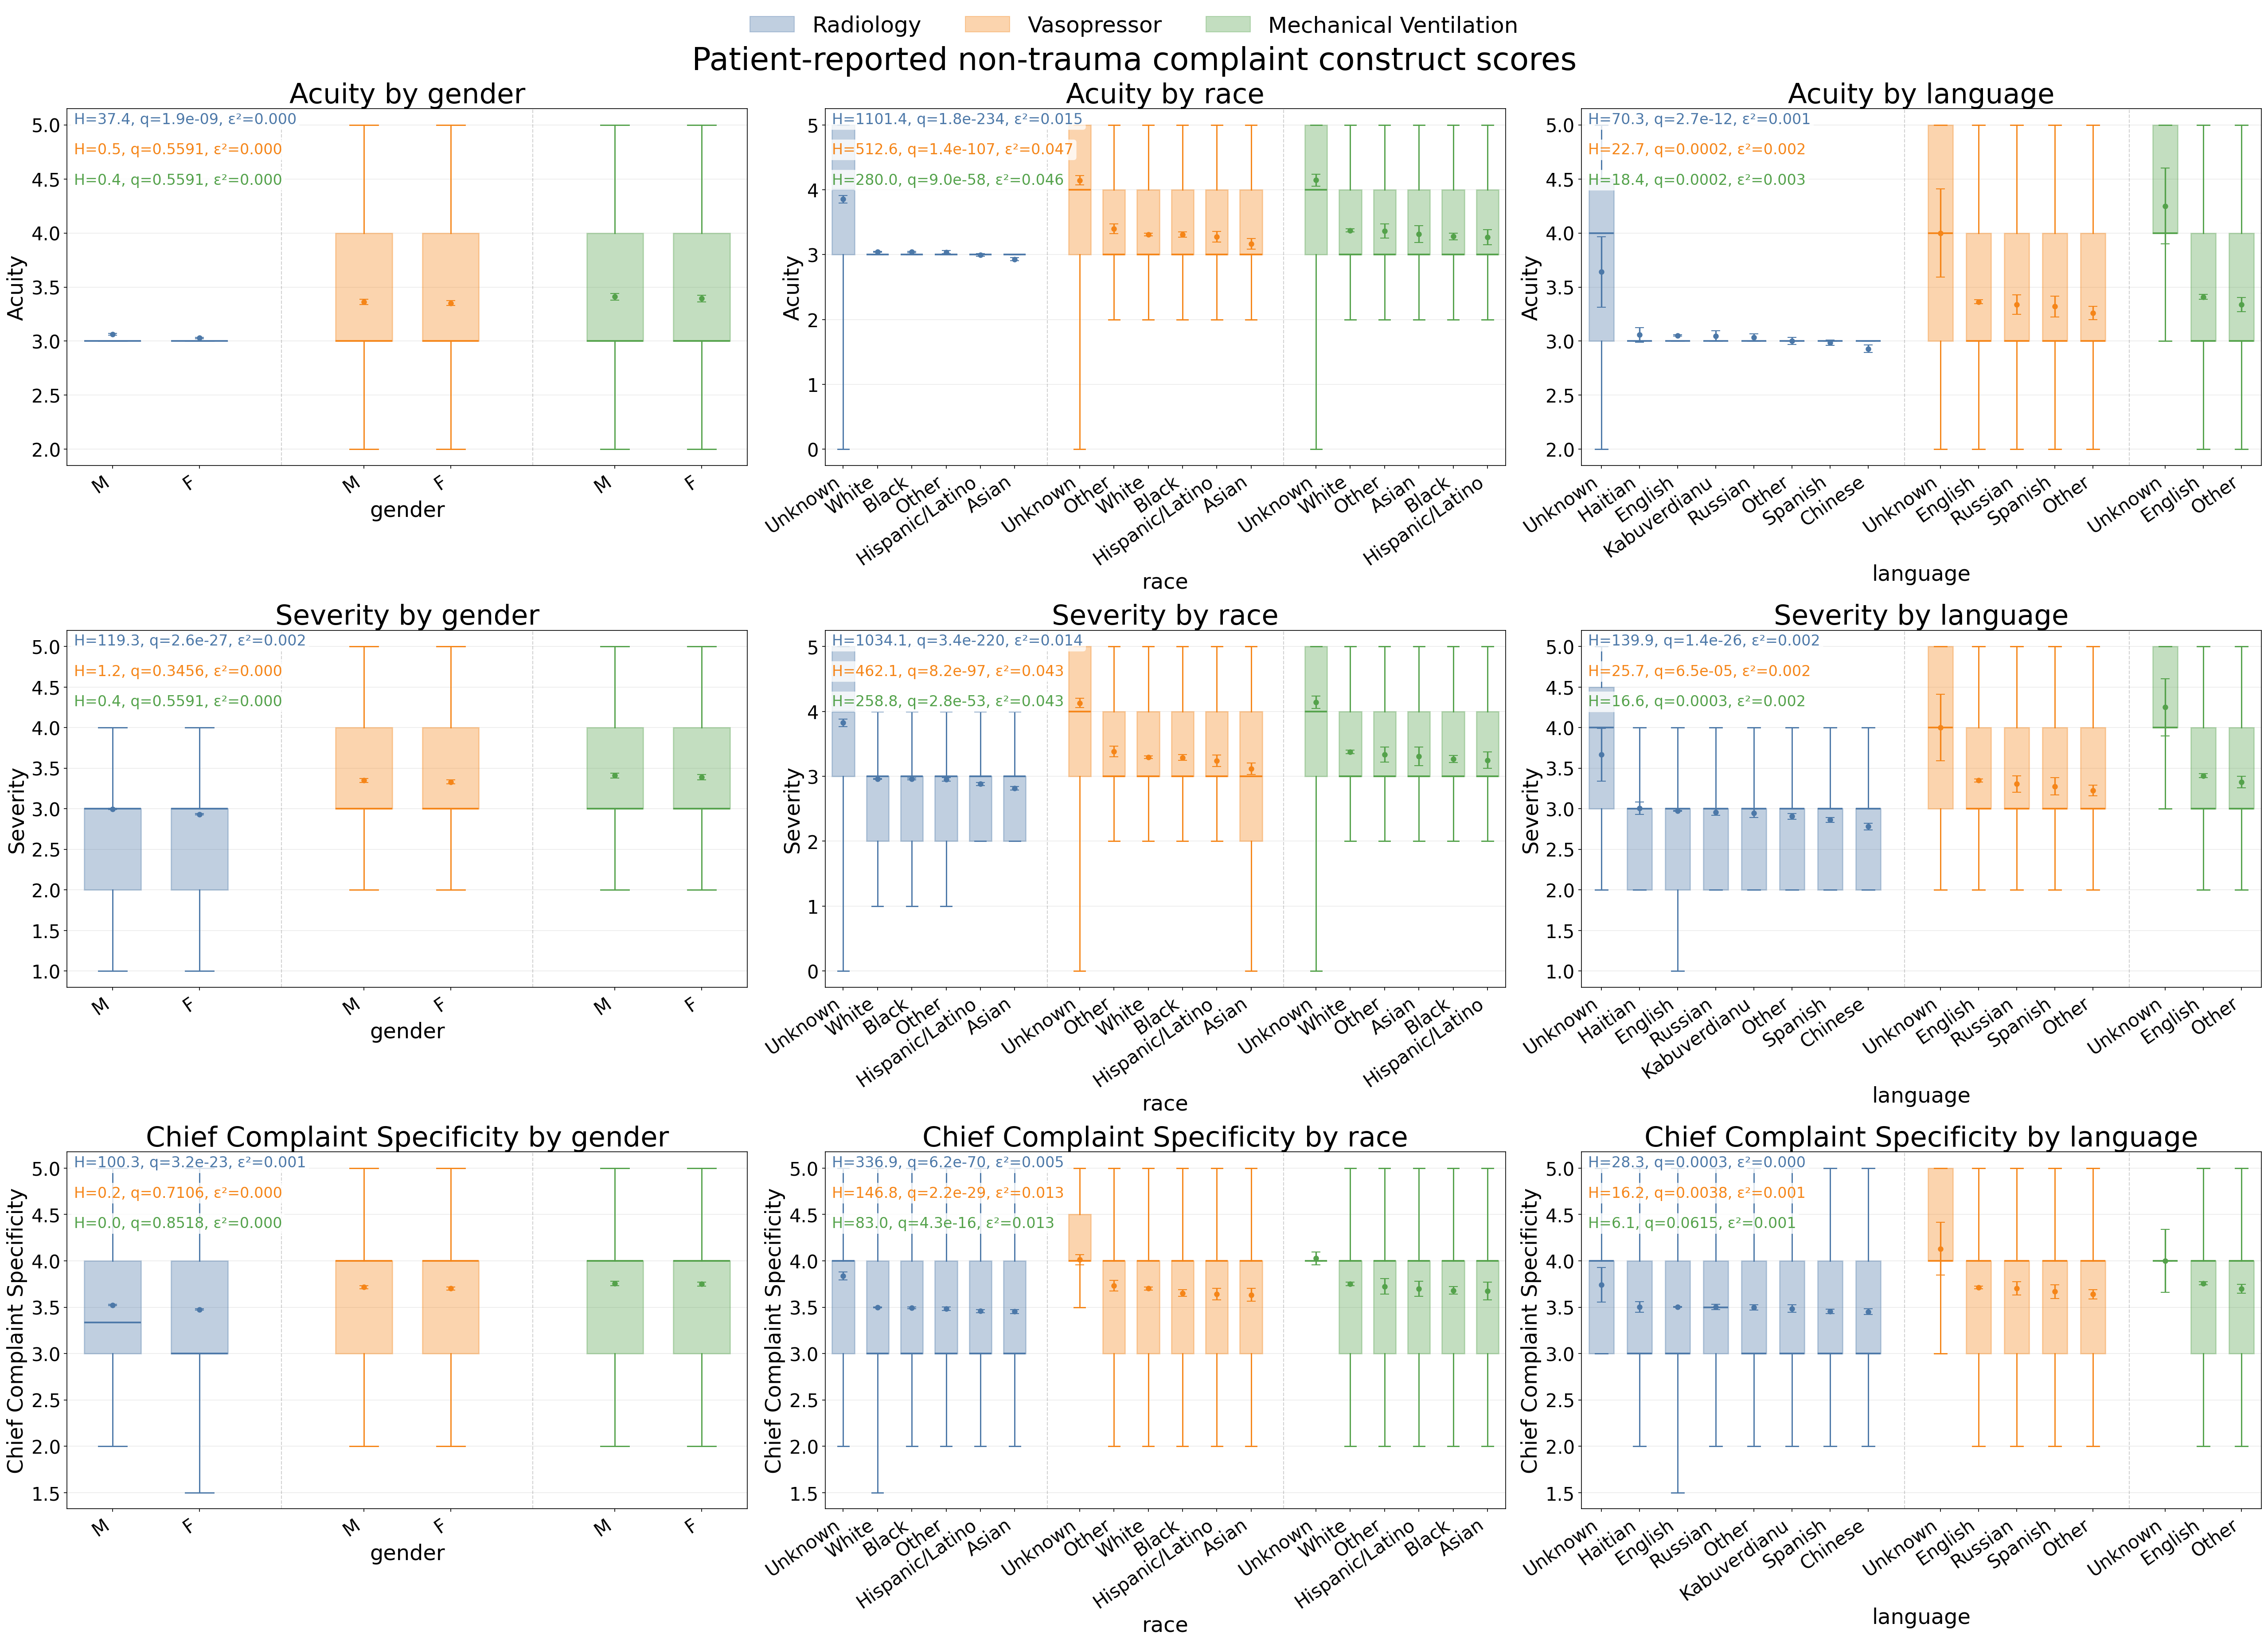

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import kruskal



TITLE_FS = 30
LABEL_FS = 23
TICK_FS = 20
TEXT_FS = 16
SUPTITLE_FS = 34
LEGEND_FS = 24

DEMOGRAPHIC_VARS = ["gender", "race", "language"]
SCORE_COLS = [
    "cc_pt_nontrauma_acuity_max",
    "cc_pt_nontrauma_severity_max",
    "cc_pt_nontrauma_specificity_mean",
]
SCORE_LABELS = {
    "cc_pt_nontrauma_acuity_max": "Acuity",
    "cc_pt_nontrauma_severity_max": "Severity",
    "cc_pt_nontrauma_specificity_mean": "Chief Complaint Specificity",
}

DATASET_ORDER = ["radiology", "pressor", "vent"]
DATASET_LABELS = {
    "radiology": "Radiology",
    "pressor": "Vasopressor",
    "vent": "Mechanical Ventilation",
}
DATASET_COLORS = {
    "radiology": "#4C78A8",
    "pressor": "#F58518",
    "vent": "#54A24B",
}


def bh_adjust(pvals: pd.Series) -> pd.Series:
    p = pd.to_numeric(pvals, errors="coerce").to_numpy(dtype=float)
    out = np.full_like(p, np.nan, dtype=float)

    mask = np.isfinite(p)
    if mask.sum() == 0:
        return pd.Series(out, index=pvals.index)

    pv = p[mask]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)

    adj = ranked * m / np.arange(1, m + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0.0, 1.0)

    restored = np.empty_like(adj)
    restored[order] = adj
    out[mask] = restored
    return pd.Series(out, index=pvals.index)


def format_p(x: float) -> str:
    if pd.isna(x):
        return "NA"
    if x < 1e-4:
        return f"{x:.1e}"
    return f"{x:.4f}"


def epsilon_squared_kruskal(H: float, n: int, k: int) -> float:
    if n <= k or k < 2:
        return np.nan
    val = (H - k + 1) / (n - k)
    return max(0.0, float(val))


def run_kw_test(df: pd.DataFrame, group_col: str, score_col: str) -> dict:
    sub = df[[group_col, score_col]].copy()
    sub[group_col] = sub[group_col].astype("string").fillna("Unknown")
    sub = sub.loc[sub[score_col].notna()].copy()

    groups = []
    for _, g in sub.groupby(group_col, observed=False):
        vals = g[score_col].astype(float).to_numpy()
        if len(vals) > 0:
            groups.append(vals)

    n = int(sum(len(x) for x in groups))
    k = int(len(groups))

    if k < 2:
        return {"n": n, "k": k, "H": np.nan, "p_value": np.nan, "eps_sq": np.nan}

    H, p = kruskal(*groups)
    eps_sq = epsilon_squared_kruskal(float(H), n=n, k=k)
    return {"n": n, "k": k, "H": float(H), "p_value": float(p), "eps_sq": eps_sq}


def collect_kw_results(merged_datasets: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []

    for dataset_name in DATASET_ORDER:
        df = merged_datasets[dataset_name]
        work = df.loc[df["cc_pt_nontrauma_has_any"] == 1].copy()

        for demo in DEMOGRAPHIC_VARS:
            if demo not in work.columns:
                continue

            for score in SCORE_COLS:
                if score not in work.columns:
                    continue

                res = run_kw_test(work, demo, score)
                rows.append(
                    {
                        "dataset": dataset_name,
                        "demographic": demo,
                        "score": score,
                        **res,
                    }
                )

    out = pd.DataFrame(rows)
    out["q_value_bh"] = bh_adjust(out["p_value"])
    return out


def dataset_level_order(df: pd.DataFrame, demo: str, score: str) -> list[str]:
    sub = df[[demo, score]].copy()
    sub[demo] = sub[demo].astype("string").fillna("Unknown")
    sub = sub.loc[sub[score].notna()].copy()

    if sub.empty:
        return []

    return (
        sub.groupby(demo, observed=False)[score]
        .mean()
        .sort_values(ascending=False)
        .index.astype(str)
        .tolist()
    )


def draw_dataset_grouped_panel(ax, merged_datasets: dict[str, pd.DataFrame], demo: str, score: str, stats_df: pd.DataFrame):
    within_gap = 0.95
    dataset_gap = 1.8
    box_width = 0.62

    xtick_positions = []
    xtick_labels = []
    divider_positions = []

    current_start = 0.0

    for d_idx, dataset_name in enumerate(DATASET_ORDER):
        df = merged_datasets[dataset_name]
        sub = df.loc[df["cc_pt_nontrauma_has_any"] == 1, [demo, score]].copy()
        sub[demo] = sub[demo].astype("string").fillna("Unknown")
        sub = sub.loc[sub[score].notna()].copy()

        level_order = dataset_level_order(sub, demo, score)
        if len(level_order) == 0:
            continue

        positions = current_start + np.arange(len(level_order)) * within_gap

        data = []
        used_positions = []
        mean_x = []
        means = []
        cis = []

        for i, lvl in enumerate(level_order):
            vals = sub.loc[sub[demo].astype(str) == lvl, score].astype(float).to_numpy()
            if len(vals) == 0:
                continue

            x = positions[i]
            data.append(vals)
            used_positions.append(x)
            mean_x.append(x)
            means.append(float(np.mean(vals)))

            if len(vals) > 1:
                sd = float(np.std(vals, ddof=1))
                se = sd / np.sqrt(len(vals))
                cis.append(1.96 * se)
            else:
                cis.append(np.nan)

        if len(data) > 0:
            bp = ax.boxplot(
                data,
                positions=used_positions,
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                medianprops={"linewidth": 1.8},
                whiskerprops={"linewidth": 1.4},
                capprops={"linewidth": 1.4},
                boxprops={"linewidth": 1.4},
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(DATASET_COLORS[dataset_name])
                patch.set_alpha(0.35)
                patch.set_edgecolor(DATASET_COLORS[dataset_name])

            for item in bp["whiskers"] + bp["caps"] + bp["medians"]:
                item.set_color(DATASET_COLORS[dataset_name])

            ax.errorbar(
                mean_x,
                means,
                yerr=cis,
                fmt="o",
                capsize=5,
                markersize=5,
                color=DATASET_COLORS[dataset_name],
                linewidth=1.6,
            )

        xtick_positions.extend(list(used_positions))
        xtick_labels.extend(level_order)

        current_start = positions[-1] + dataset_gap

        if d_idx < len(DATASET_ORDER) - 1:
            divider_positions.append(positions[-1] + dataset_gap / 2)

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, rotation=35, ha="right", fontsize=TICK_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_xlabel(demo, fontsize=LABEL_FS)
    ax.set_ylabel(SCORE_LABELS[score], fontsize=LABEL_FS)
    ax.set_title(f"{SCORE_LABELS[score]} by {demo}", fontsize=TITLE_FS)
    ax.grid(axis="y", alpha=0.25)

    for x in divider_positions:
        ax.axvline(x=x, color="gray", linestyle="--", linewidth=1.0, alpha=0.35)

    y0 = 0.99
    dy = 0.085
    for idx, dataset_name in enumerate(DATASET_ORDER):
        row = stats_df.loc[
            (stats_df["dataset"] == dataset_name)
            & (stats_df["demographic"] == demo)
            & (stats_df["score"] == score)
        ]
        if row.empty:
            continue
        row = row.iloc[0]

        txt = f"H={row['H']:.1f}, q={format_p(row['q_value_bh'])}, ε²={row['eps_sq']:.3f}"
        ax.text(
            0.01,
            y0 - idx * dy,
            txt,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=TEXT_FS,
            color=DATASET_COLORS[dataset_name],
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )


kw_results = collect_kw_results(merged_datasets)
kw_results.to_csv(FIG_DIR / "cc_nontrauma_kw_results.csv", index=False)

fig, axes = plt.subplots(3, 3, figsize=(34, 24), constrained_layout=True)

for i, score in enumerate(SCORE_COLS):
    for j, demo in enumerate(DEMOGRAPHIC_VARS):
        draw_dataset_grouped_panel(
            ax=axes[i, j],
            merged_datasets=merged_datasets,
            demo=demo,
            score=score,
            stats_df=kw_results,
        )

fig.suptitle(
    "Patient-reported non-trauma complaint construct scores",
    fontsize=SUPTITLE_FS,
)

legend_handles = [
    Patch(
        facecolor=DATASET_COLORS[name],
        edgecolor=DATASET_COLORS[name],
        alpha=0.35,
        label=DATASET_LABELS[name],
    )
    for name in DATASET_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_FS,
)

out_path = FIG_DIR / "cc_nontrauma_grouped.pdf"
fig.savefig(out_path, bbox_inches="tight")
plt.show()

In [8]:
def run_one_way_anova(df: pd.DataFrame, dataset_name: str, min_group_n: int = 5) -> pd.DataFrame:
    work = df.loc[df["cc_pt_nontrauma_has_any"] == 1].copy()
    rows = []

    for demo in DEMOGRAPHIC_VARS:
        if demo not in work.columns:
            continue

        for score in SCORE_COLS:
            sub = work[[demo, score]].copy()
            sub[demo] = sub[demo].astype("string").fillna("Unknown")
            sub = sub.loc[sub[score].notna()].copy()
            if sub.empty:
                continue

            groups = []
            kept_levels = []
            for level, g in sub.groupby(demo, dropna=False):
                vals = g[score].astype(float).to_numpy()
                if len(vals) >= min_group_n:
                    groups.append(vals)
                    kept_levels.append(str(level))

            if len(groups) < 2:
                rows.append(
                    {
                        "dataset": dataset_name,
                        "demographic": demo,
                        "score": score,
                        "test": "anova",
                        "n_groups": len(groups),
                        "levels": " | ".join(kept_levels),
                        "f_stat": np.nan,
                        "p_value": np.nan,
                        "tested_n": int(sum(len(g) for g in groups)),
                    }
                )
                continue

            f_stat, p_value = stats.f_oneway(*groups)
            rows.append(
                {
                    "dataset": dataset_name,
                    "demographic": demo,
                    "score": score,
                    "test": "anova",
                    "n_groups": len(groups),
                    "levels": " | ".join(kept_levels),
                    "f_stat": float(f_stat),
                    "p_value": float(p_value),
                    "tested_n": int(sum(len(g) for g in groups)),
                }
            )

    return pd.DataFrame(rows)

anova_results = pd.concat(
    [run_one_way_anova(df, dataset_name=name) for name, df in merged_datasets.items()],
    ignore_index=True,
)

anova_results["p_value_bh"] = np.nan
for score in anova_results["score"].dropna().unique():
    mask = anova_results["score"].eq(score) & anova_results["p_value"].notna()
    p = anova_results.loc[mask, "p_value"].to_numpy()
    if len(p) == 0:
        continue
    order = np.argsort(p)
    ranked = np.empty_like(order, dtype=float)
    m = len(p)
    prev = 1.0
    for rank_idx in range(m - 1, -1, -1):
        idx = order[rank_idx]
        bh = min(prev, p[idx] * m / (rank_idx + 1))
        ranked[idx] = bh
        prev = bh
    anova_results.loc[mask, "p_value_bh"] = ranked

anova_results.to_csv(OUT_DIR / "cc_patient_reported_nontrauma_anova_results.csv", index=False)

display(anova_results.sort_values(["p_value", "dataset", "demographic"]).reset_index(drop=True))


,dataset,demographic,score,test,n_groups,levels,f_stat,p_value,tested_n,p_value_bh
0,radiology,race,cc_pt_nontrauma_acuity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,304.323840,1.482197e-323,73395,1.333977e-322
1,radiology,race,cc_pt_nontrauma_severity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,288.740179,5.015072e-307,73395,4.513565e-306
2,pressor,race,cc_pt_nontrauma_acuity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,122.318704,2.569305e-126,10742,1.156187e-125
3,pressor,race,cc_pt_nontrauma_severity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,108.793036,1.875108e-112,10742,8.437986e-112
4,radiology,race,cc_pt_nontrauma_specificity_mean,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,78.319667,3.202767e-82,73395,2.882491e-81
5,vent,race,cc_pt_nontrauma_acuity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,66.985336,2.730806e-68,5922,8.192418e-68
6,vent,race,cc_pt_nontrauma_severity_max,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,60.504941,1.122368e-61,5922,3.367103e-61
7,radiology,language,cc_pt_nontrauma_severity_max,anova,8,Chinese | English | Haitian | Kabuverdianu | O...,21.552193,2.872200e-29,73395,6.462451e-29
8,pressor,race,cc_pt_nontrauma_specificity_mean,anova,6,Asian | Black | Hispanic/Latino | Other | Unkn...,28.910983,3.055139e-29,10742,1.374813e-28
9,radiology,gender,cc_pt_nontrauma_severity_max,anova,2,F | M,114.801570,9.104009e-27,73395,1.638722e-26


In [16]:
def summarize_values(vals):
    return {
        "n": len(vals),
        "mean": np.mean(vals),
        "ci_95": 1.96 * np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan,
        "min": np.min(vals),
        "q1": np.percentile(vals, 25),
        "median": np.median(vals),
        "q3": np.percentile(vals, 75),
        "max": np.max(vals),
    }


for score in SCORE_COLS:
    for demo in DEMOGRAPHIC_VARS:
        print("\n" + "=" * 100)
        print(f"FIGURE PANEL: {SCORE_LABELS[score]} by {demo}")
        print("=" * 100)

        for dataset_name in DATASET_ORDER:
            df = merged_datasets[dataset_name]
            sub = df.loc[df["cc_pt_nontrauma_has_any"] == 1, [demo, score]].copy()
            sub[demo] = sub[demo].astype("string").fillna("Unknown")
            sub = sub.loc[sub[score].notna()].copy()

            level_order = dataset_level_order(sub, demo, score)

            print(f"\nDATASET: {DATASET_LABELS[dataset_name]}")
            print("-" * 80)

            row = kw_results.loc[
                (kw_results["dataset"] == dataset_name)
                & (kw_results["demographic"] == demo)
                & (kw_results["score"] == score)
            ]

            if len(row) > 0:
                row = row.iloc[0]
                print(
                    f"Annotation shown on plot: "
                    f"H={row['H']:.1f}, "
                    f"q={format_p(row['q_value_bh'])}, "
                    f"ε²={row['eps_sq']:.3f}"
                )

            print("\nBoxplots shown, in x-axis order:")

            for level in level_order:
                vals = sub.loc[sub[demo].astype(str) == level, score].astype(float).to_numpy()
                s = summarize_values(vals)

                print(
                    f"{level}: "
                    f"n={s['n']}, "
                    f"mean={s['mean']:.4f}, "
                    f"95% CI half-width={s['ci_95']:.4f}, "
                    f"min={s['min']:.4f}, "
                    f"Q1={s['q1']:.4f}, "
                    f"median={s['median']:.4f}, "
                    f"Q3={s['q3']:.4f}, "
                    f"max={s['max']:.4f}"
                )


FIGURE PANEL: Acuity by gender

DATASET: Radiology
--------------------------------------------------------------------------------
Annotation shown on plot: H=37.4, q=1.9e-09, ε²=0.000

Boxplots shown, in x-axis order:
M: n=34846, mean=3.0645, 95% CI half-width=0.0079, min=0.0000, Q1=3.0000, median=3.0000, Q3=3.0000, max=5.0000
F: n=38549, mean=3.0296, 95% CI half-width=0.0072, min=0.0000, Q1=3.0000, median=3.0000, Q3=3.0000, max=5.0000

DATASET: Vasopressor
--------------------------------------------------------------------------------
Annotation shown on plot: H=0.5, q=0.5591, ε²=0.000

Boxplots shown, in x-axis order:
M: n=5456, mean=3.3622, 95% CI half-width=0.0232, min=0.0000, Q1=3.0000, median=3.0000, Q3=4.0000, max=5.0000
F: n=5286, mean=3.3511, 95% CI half-width=0.0229, min=0.0000, Q1=3.0000, median=3.0000, Q3=4.0000, max=5.0000

DATASET: Mechanical Ventilation
--------------------------------------------------------------------------------
Annotation shown on plot: H=0.4, q

Interpretation notes:

- The construct is restricted to lookup rows with `is_informative == True`, `trauma_status == 'non_trauma'`, and `symptom_type == 'symptom'`.
- Encounter-level aggregation uses `max` for acuity and severity, and `mean` for specificity, exactly as requested.
- The merged datasets include `cc_pt_nontrauma_has_any` and `cc_pt_nontrauma_component_n` so you can restrict later models to rows with at least one eligible complaint component.
- The ANOVA here is one-way ANOVA within each dataset × demographic variable × score. If you later want a robustness check that is less sensitive to unequal variances or non-normality, add Kruskal-Wallis in a second cell.